- <a href='#0'>0. Introduction</a>  
- <a href='#1'>1. Get the Data</a>
- <a href='#2'>2. Check the Data</a>
- <a href='#3'> 3. Explore the data</a>
    - <a href='#3-1'>3.1 Categorical features</a>
    - <a href='#3-2'>3.2 Numerical features</a>
    - <a href='#3-3'>3.3 Categorical features by label</a>
    - <a href='#3-4'>3.4 Numerical features by label</a>
    - <a href='#3-5'>3.5 Correlation Matrix</a>
- <a href='#4'> 4. A further exploration on application table</a>
    - <a href='#4-1'>4.1 Impute missing values</a>
    - <a href='#4-2'>4.2 Create more feature</a>
    - <a href='#4-3'>4.3 Train model</a>
    - <a href='#4-4'>4.4 Feature importance</a>
    - <a href='#4-5'>4.5 Prediction</a>

## <a id='0'>0. Introduction</a>

 [Home Credit](http://www.homecredit.net/[](http://) is an international non-bank financial institution founded in 1997 in the Czech Republic. The company operates in 14 countries and focuses on lending primarily to people with little or no credit history. 

Home Credit strives to broaden financial inclusion for the unbanked population by providing a positive and safe borrowing experience. In order to make sure this underserved population has a positive loan experience, Home Credit makes use of a variety of alternative data--including telco and transactional information--**to predict their clients' repayment abilities.**

While Home Credit is currently using various statistical and machine learning methods to make these predictions, **they're challenging Kagglers to help them unlock the full potential of their data**. Doing so will ensure that clients capable of repayment are not rejected and that loans are given with a principal, maturity, and repayment calendar that will empower their clients to be successful.
![](http://www.homecredit.net/~/media/Images/H/Home-Credit-Group/image-gallery/full/image-gallery-01-11-2016-b.png)

> ## <a id='1'>1. Get the data</a>

In [1]:
import os
print(os.getcwd())
print(os.listdir())

c:\โครงงาน AI\Kaggle-Home-Credit-Default-Risk-Solution
['.git', '.ipynb_checkpoints', 'EDA.ipynb', 'Feature', 'Feature Selection.ipynb', 'input', 'Model', 'README.md']


In [2]:
p = r'input/previous_application.csv'
print(os.path.exists(p))
print(os.path.getsize(p))

True
404973293


In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
color = sns.color_palette()
import gc
import warnings
import time
warnings.filterwarnings("ignore")

In [2]:
application_train = pd.read_csv('input/application_train.csv')
application_test= pd.read_csv('input/application_test.csv')
bureau = pd.read_csv('input/bureau.csv')
bureau_balance = pd.read_csv('input/bureau_balance.csv')
POS_CASH_balance = pd.read_csv('input/POS_CASH_balance.csv')
credit_card_balance = pd.read_csv('input/credit_card_balance.csv')
previous_application = pd.read_csv('input/previous_application.csv')
installments_payments = pd.read_csv('input/installments_payments.csv')

This file contains descriptions for the columns in the various data files.

<img src="https://storage.googleapis.com/kaggle-media/competitions/home-credit/home_credit.png" width="800"></img>

In [3]:
print('------------main------------')
print('application_train:', application_train.shape[0], "rows and", application_train.shape[1],'columns')
print('application_test:', application_test.shape[0], "rows and", application_test.shape[1],'columns')
print('      ')
print('------------others------------')
print('POS_CASH_balance:', POS_CASH_balance.shape[0], "rows and", POS_CASH_balance.shape[1],'columns')
print('bureau:', bureau.shape[0], "rows and", bureau.shape[1],'columns')
print('bureau_balance:', bureau_balance.shape[0], "rows and", bureau_balance.shape[1],'columns')
print('previous_application:', previous_application.shape[0], "rows and", previous_application.shape[1],'columns')
print('installments_payments:', installments_payments.shape[0], "rows and", installments_payments.shape[1],'columns')
print('credit_card_balance:', credit_card_balance.shape[0], "rows and", credit_card_balance.shape[1],'columns')

------------main------------
application_train: 307511 rows and 122 columns
application_test: 48744 rows and 121 columns
      
------------others------------
POS_CASH_balance: 10001358 rows and 8 columns
bureau: 1716428 rows and 17 columns
bureau_balance: 27299925 rows and 3 columns
previous_application: 1670214 rows and 37 columns
installments_payments: 13605401 rows and 8 columns
credit_card_balance: 3840312 rows and 23 columns


## <a id='2'>2. Check the data</a>
### 2.1 application train / test

In [4]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
application_train.columns.values

array(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE',
       'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
       'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE',
       'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION',
       'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
       'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3',

In [6]:
def find_missing(data):
    # number of missing values
    count_missing = data.isnull().sum().values
    # total records
    total = data.shape[0]
    # percentage of missing
    ratio_missing = count_missing/total
    # return a dataframe to show: feature name, # of missing and % of missing
    return pd.DataFrame(data={'missing_count':count_missing, 'missing_ratio':ratio_missing}, index=data.columns.values)
find_missing(application_train).head(12)

,missing_count,missing_ratio
SK_ID_CURR,0,0.000000
TARGET,0,0.000000
NAME_CONTRACT_TYPE,0,0.000000
CODE_GENDER,0,0.000000
FLAG_OWN_CAR,0,0.000000
FLAG_OWN_REALTY,0,0.000000
CNT_CHILDREN,0,0.000000
AMT_INCOME_TOTAL,0,0.000000
AMT_CREDIT,0,0.000000
AMT_ANNUITY,12,0.000039


### 2.2 POS_CASH_balance

In [7]:
POS_CASH_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [8]:
POS_CASH_balance.columns.values

array(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT',
       'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD',
       'SK_DPD_DEF'], dtype=object)

In [9]:
find_missing(POS_CASH_balance).head(12)

,missing_count,missing_ratio
SK_ID_PREV,0,0.000000
SK_ID_CURR,0,0.000000
MONTHS_BALANCE,0,0.000000
CNT_INSTALMENT,26071,0.002607
CNT_INSTALMENT_FUTURE,26087,0.002608
NAME_CONTRACT_STATUS,0,0.000000
SK_DPD,0,0.000000
SK_DPD_DEF,0,0.000000


### 2.3 bureau

In [10]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [11]:
bureau.columns.values

array(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE',
       'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT',
       'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE',
       'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY'], dtype=object)

In [12]:
find_missing(bureau).head(12)

,missing_count,missing_ratio
SK_ID_CURR,0,0.000000
SK_ID_BUREAU,0,0.000000
CREDIT_ACTIVE,0,0.000000
CREDIT_CURRENCY,0,0.000000
DAYS_CREDIT,0,0.000000
CREDIT_DAY_OVERDUE,0,0.000000
DAYS_CREDIT_ENDDATE,105553,0.061496
DAYS_ENDDATE_FACT,633653,0.369170
AMT_CREDIT_MAX_OVERDUE,1124488,0.655133
CNT_CREDIT_PROLONG,0,0.000000


### 2.4 bureau_balance

In [13]:
bureau_balance.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [14]:
bureau_balance.columns.values

array(['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS'], dtype=object)

In [15]:
find_missing(bureau_balance).head(12)

,missing_count,missing_ratio
SK_ID_BUREAU,0,0.0
MONTHS_BALANCE,0,0.0
STATUS,0,0.0


### 2.5 credit_card_balance

In [16]:
credit_card_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [17]:
credit_card_balance.columns.values

array(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE',
       'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
       'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
       'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY',
       'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
       'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE',
       'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT',
       'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT',
       'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM',
       'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF'], dtype=object)

In [18]:
find_missing(credit_card_balance).head(12)

,missing_count,missing_ratio
SK_ID_PREV,0,0.000000
SK_ID_CURR,0,0.000000
MONTHS_BALANCE,0,0.000000
AMT_BALANCE,0,0.000000
AMT_CREDIT_LIMIT_ACTUAL,0,0.000000
AMT_DRAWINGS_ATM_CURRENT,749816,0.195249
AMT_DRAWINGS_CURRENT,0,0.000000
AMT_DRAWINGS_OTHER_CURRENT,749816,0.195249
AMT_DRAWINGS_POS_CURRENT,749816,0.195249
AMT_INST_MIN_REGULARITY,305236,0.079482


### 2.6 previous_application

In [19]:
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
previous_application.columns.values

array(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT',
       'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT',
       'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT',
       'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED',
       'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION',
       'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE',
       'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO',
       'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA',
       'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP',
       'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE',
       'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION',
       'NFLAG_INSURED_ON_APPROVAL'], dtype=object)

In [21]:
find_missing(previous_application).head(12)

,missing_count,missing_ratio
SK_ID_PREV,0,0.000000e+00
SK_ID_CURR,0,0.000000e+00
NAME_CONTRACT_TYPE,0,0.000000e+00
AMT_ANNUITY,372235,2.228667e-01
AMT_APPLICATION,0,0.000000e+00
AMT_CREDIT,1,5.987257e-07
AMT_DOWN_PAYMENT,895844,5.363648e-01
AMT_GOODS_PRICE,385515,2.308177e-01
WEEKDAY_APPR_PROCESS_START,0,0.000000e+00
HOUR_APPR_PROCESS_START,0,0.000000e+00


### 2.7 installments_payments

In [22]:
installments_payments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [23]:
installments_payments.columns.values

array(['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION',
       'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT',
       'AMT_INSTALMENT', 'AMT_PAYMENT'], dtype=object)

In [24]:
find_missing(installments_payments).head(12)

,missing_count,missing_ratio
SK_ID_PREV,0,0.000000
SK_ID_CURR,0,0.000000
NUM_INSTALMENT_VERSION,0,0.000000
NUM_INSTALMENT_NUMBER,0,0.000000
DAYS_INSTALMENT,0,0.000000
DAYS_ENTRY_PAYMENT,2905,0.000214
AMT_INSTALMENT,0,0.000000
AMT_PAYMENT,2905,0.000214


## <a id='3'>3. Explore the data</a>

### <a id='3-1'>3.1 Categorical features</a>
#### Label

In [25]:
application_train.TARGET.value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [30]:
def plot_categorical(data, col, size=(8, 4), xlabel_angle=0, title='', xtick=None):
    '''Plot categorical feature distribution'''
    plotdata = data[col].value_counts(dropna=False) / len(data)
    plt.figure(figsize=size)
    sns.barplot(x=plotdata.index.astype(str), y=plotdata.values)

    if xtick is not None and len(xtick) == len(plotdata.index):
        plt.xticks(range(len(plotdata.index)), xtick, rotation=xlabel_angle)
    else:
        plt.xticks(rotation=xlabel_angle)

    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.title(title if title else col)
    plt.tight_layout()
    plt.show()


### Occupation Type

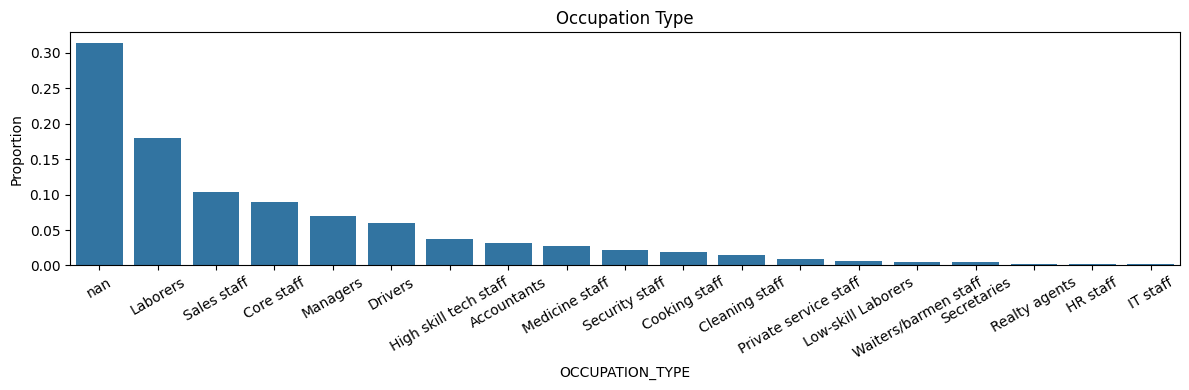

In [31]:
plot_categorical(data=application_train, col='OCCUPATION_TYPE', size=[12 ,4], xlabel_angle=30, title='Occupation Type')

#### Gender

### Income Type

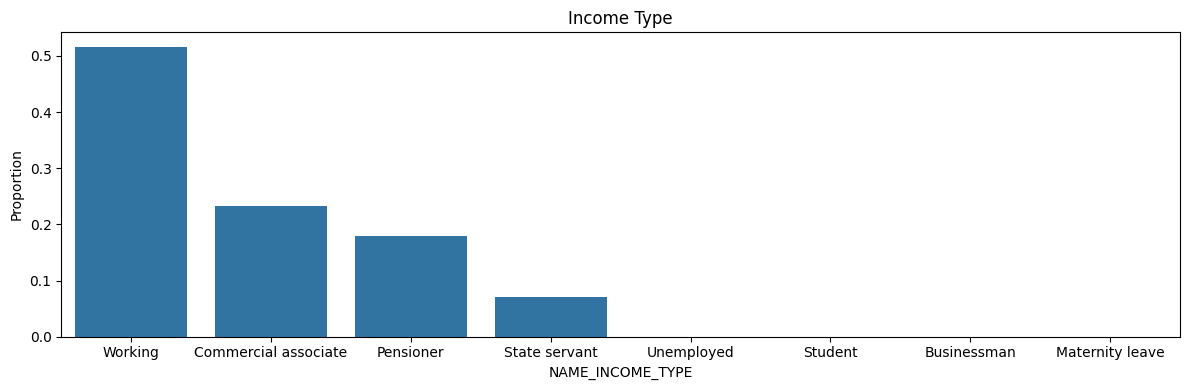

In [32]:
plot_categorical(data=application_train, col='NAME_INCOME_TYPE', size=[12 ,4], xlabel_angle=0, title='Income Type')

### House Type

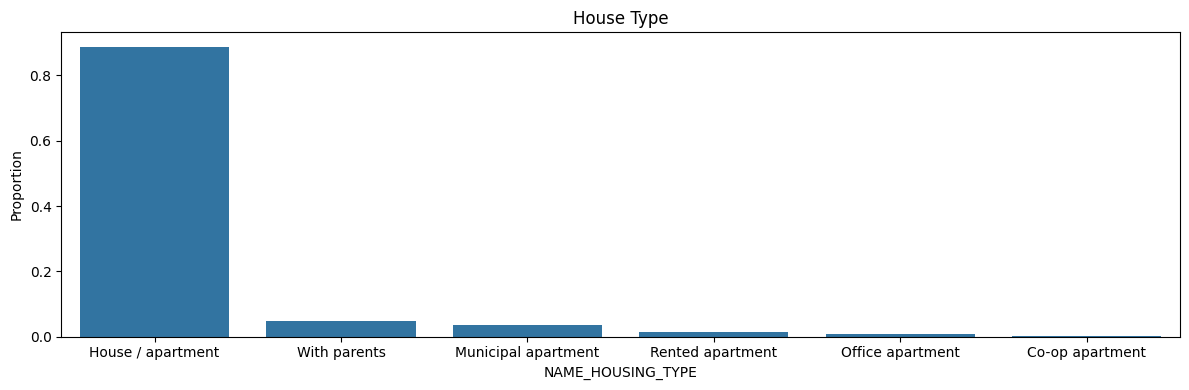

In [33]:
plot_categorical(data=application_train, col='NAME_HOUSING_TYPE', size=[12 ,4], xlabel_angle=0, title='House Type')

### <a id='3-2'>3.2 Numerical features</a>
#### Credit Amount

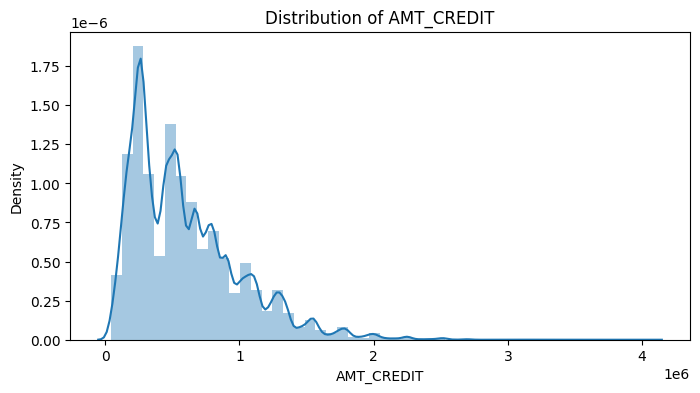

In [34]:
def plot_numerical(data, col, size=[8, 4], bins=50):
    '''use this for ploting the distribution of numercial features'''
    plt.figure(figsize=size)
    plt.title("Distribution of %s" % col)
    sns.distplot(data[col].dropna(), kde=True,bins=bins)
    plt.show()
plot_numerical(application_train, 'AMT_CREDIT')

#### Annuity Amount

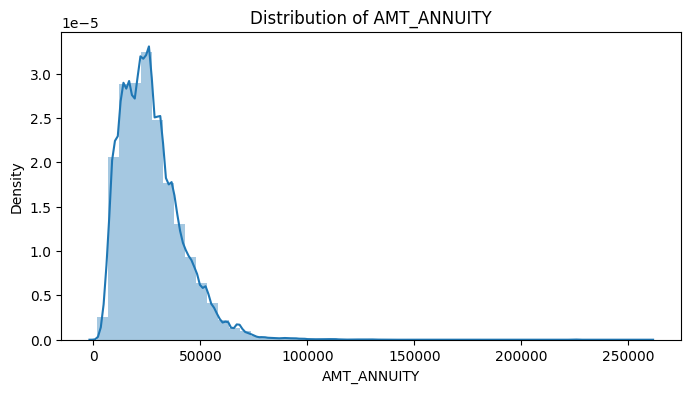

In [35]:
plot_numerical(application_train, 'AMT_ANNUITY')

### Days employed

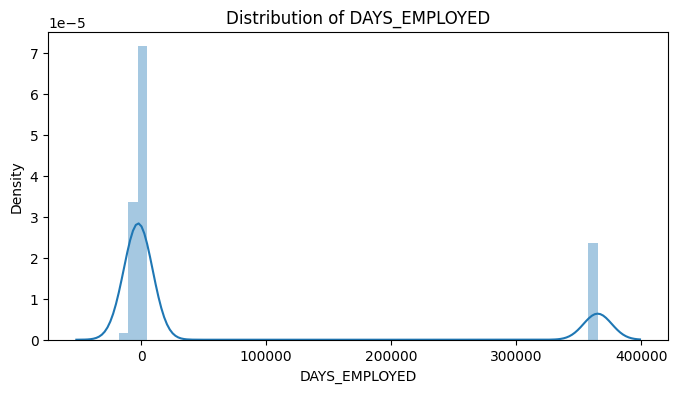

In [36]:
plot_numerical(application_train, 'DAYS_EMPLOYED')

### <a id='3-3'>3.3 Categorical features by label</a>
#### Gender

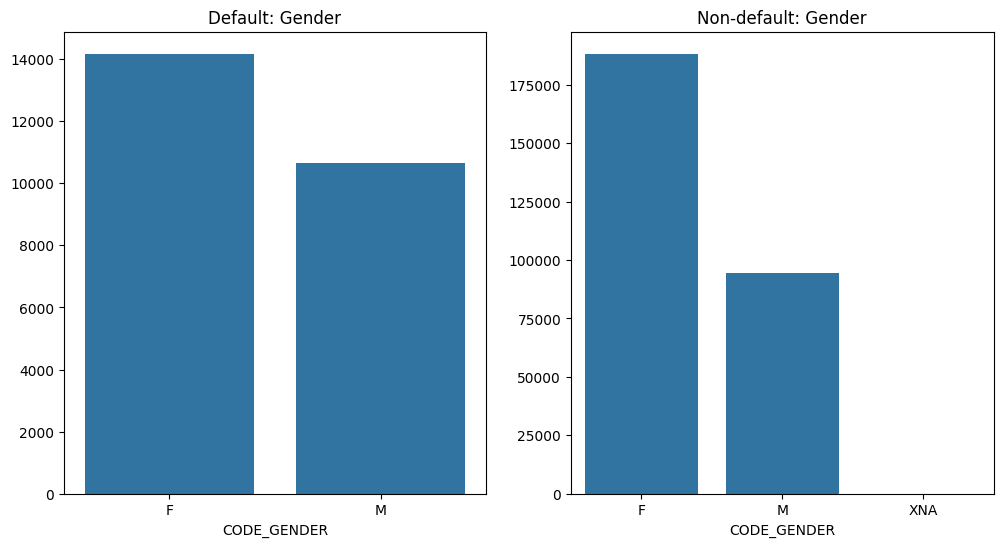

In [37]:
def plot_categorical_bylabel(data, col, size=[12 ,6], xlabel_angle=0, title=''):
    '''use it to compare the distribution between label 1 and label 0'''
    plt.figure(figsize = size)
    l1 = data.loc[data.TARGET==1, col].value_counts()
    l0 = data.loc[data.TARGET==0, col].value_counts()
    plt.subplot(1,2,1)
    sns.barplot(x = l1.index, y=l1.values)
    plt.title('Default: '+title)
    plt.xticks(rotation=xlabel_angle)
    plt.subplot(1,2,2)
    sns.barplot(x = l0.index, y=l0.values)
    plt.title('Non-default: '+title)
    plt.xticks(rotation=xlabel_angle)
    plt.show()
plot_categorical_bylabel(application_train, 'CODE_GENDER', title='Gender')

#### Education Type

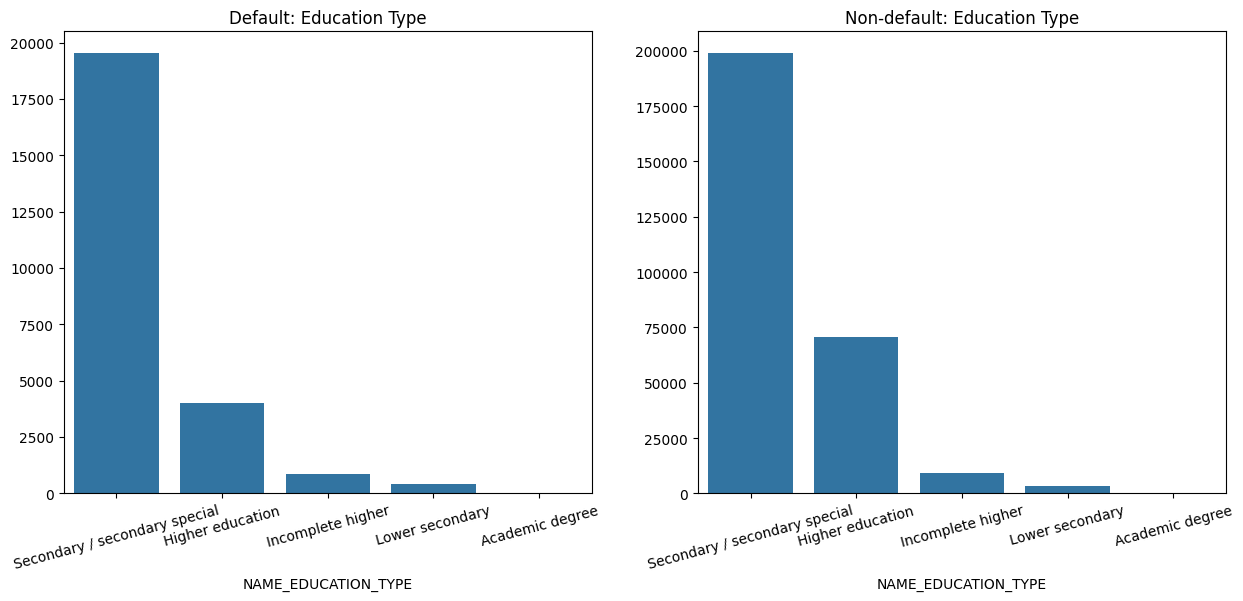

In [38]:
plot_categorical_bylabel(application_train, 'NAME_EDUCATION_TYPE', size=[15 ,6], xlabel_angle=15, title='Education Type')

### <a id='3-4'>3.4 Numerical features by label</a>
#### EXT_SOURCE_1

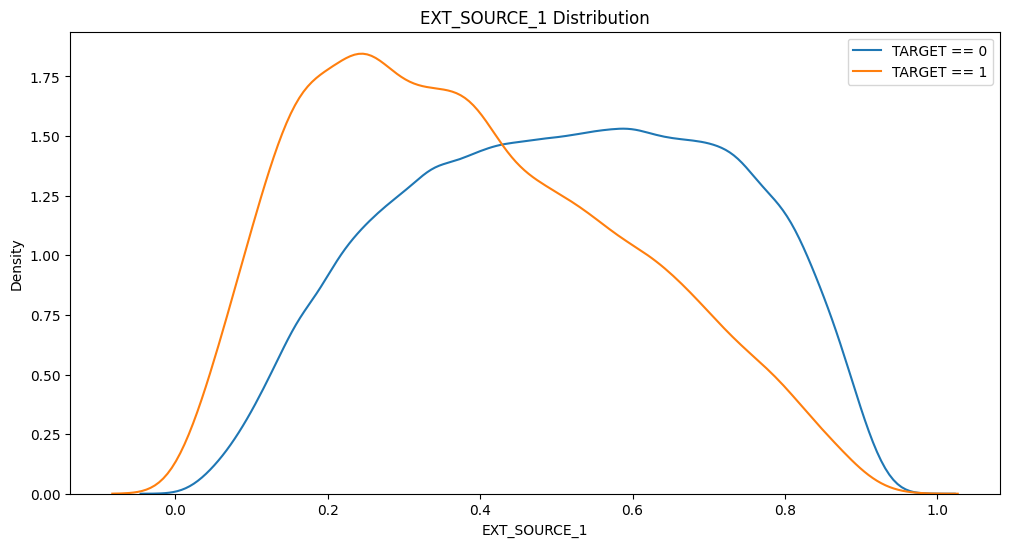

The correlation between EXT_SOURCE_1 and the TARGET is -0.1553
Median value for TARGET == 0: 0.5175
Median value for TARGET == 1: 0.3617


In [40]:
def plot_numerical_bylabel(data, col, size=(12, 6)):
    plt.figure(figsize=size)

    corr = data['TARGET'].corr(data[col])

    avg_repaid = data.loc[data['TARGET'] == 0, col].median()
    avg_not_repaid = data.loc[data['TARGET'] == 1, col].median()

    sns.kdeplot(data=data.loc[data['TARGET'] == 0, col].dropna(), label='TARGET == 0')
    sns.kdeplot(data=data.loc[data['TARGET'] == 1, col].dropna(), label='TARGET == 1')

    plt.xlabel(col)
    plt.ylabel('Density')
    plt.title(f'{col} Distribution')
    plt.legend()
    plt.show()

    print(f'The correlation between {col} and the TARGET is {corr:0.4f}')
    print(f'Median value for TARGET == 0: {avg_repaid:0.4f}')
    print(f'Median value for TARGET == 1: {avg_not_repaid:0.4f}')
plot_numerical_bylabel(application_train, 'EXT_SOURCE_1')

#### EXT_SOURCE_2

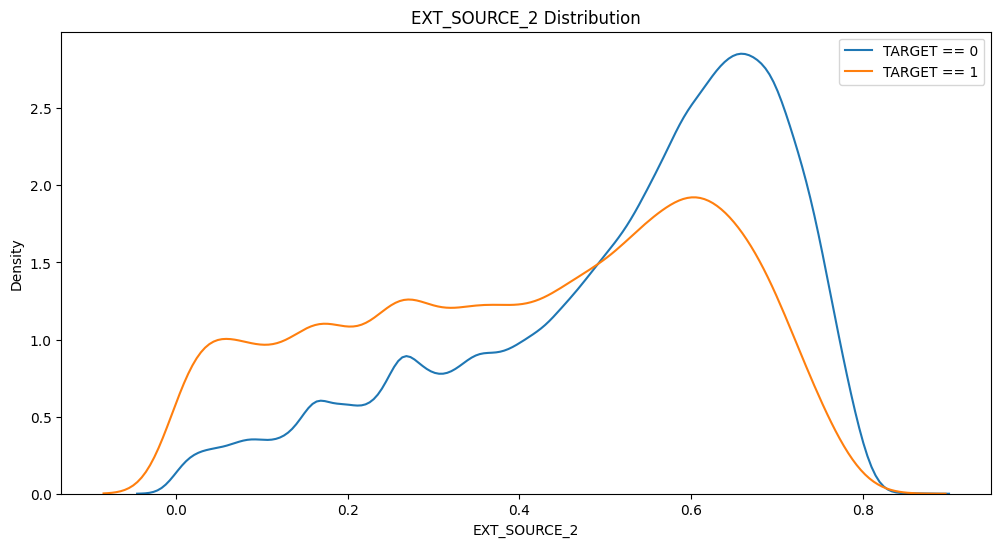

The correlation between EXT_SOURCE_2 and the TARGET is -0.1605
Median value for TARGET == 0: 0.5739
Median value for TARGET == 1: 0.4404


In [41]:
plot_numerical_bylabel(application_train, 'EXT_SOURCE_2')

#### EXT_SOURCE_3

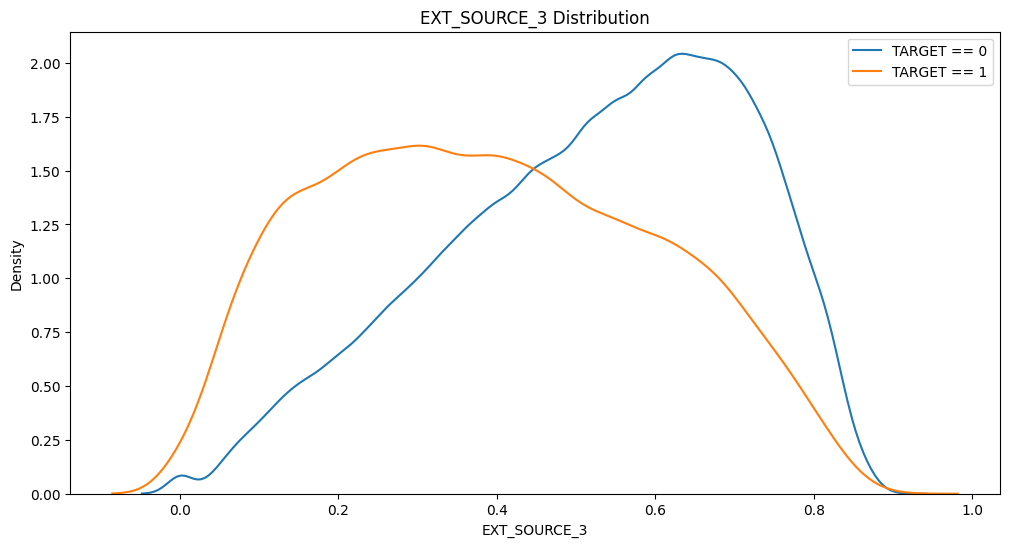

The correlation between EXT_SOURCE_3 and the TARGET is -0.1789
Median value for TARGET == 0: 0.5460
Median value for TARGET == 1: 0.3791


In [42]:
plot_numerical_bylabel(application_train, 'EXT_SOURCE_3')

 ### <a id='3-5'>3.5 Correlation Matrix</a>

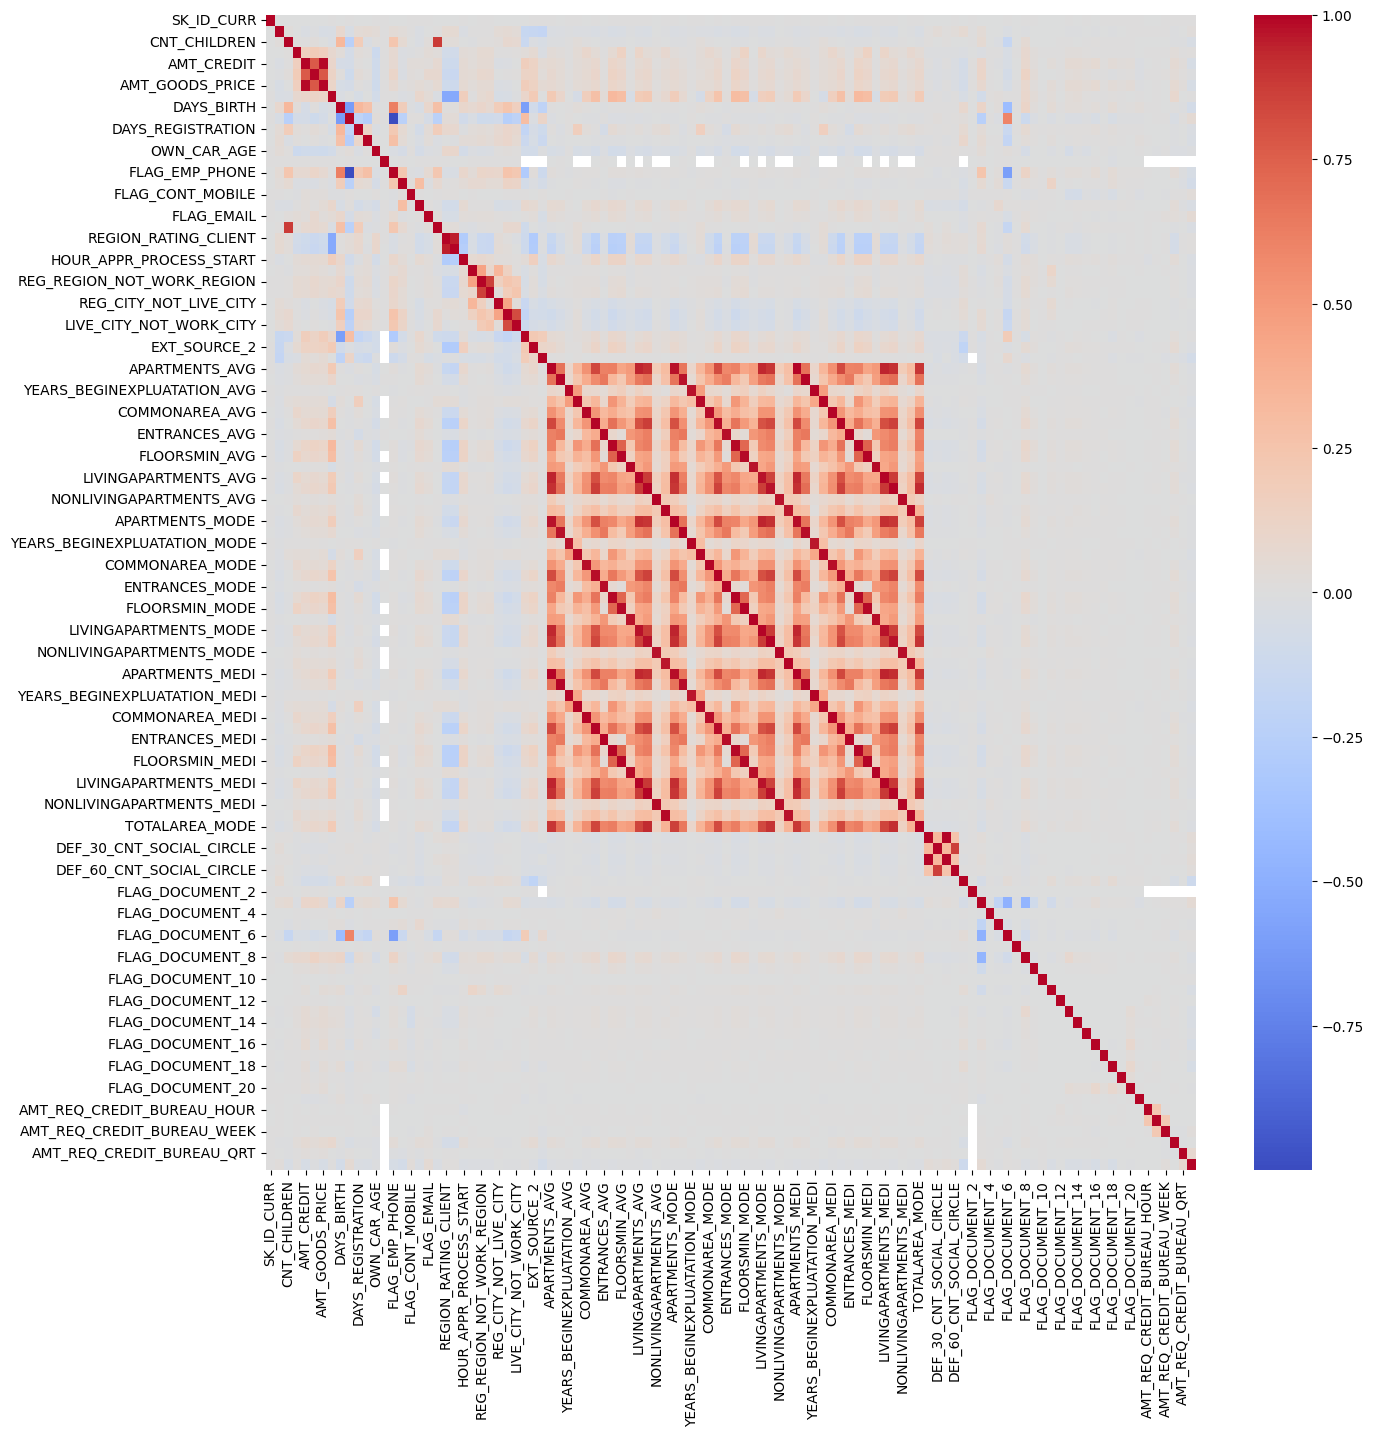

In [44]:
corr_mat = application_train.corr(numeric_only=True)
plt.figure(figsize=(15, 15))
sns.heatmap(corr_mat, annot=False, cmap='coolwarm')
plt.show()


 ## <a id='4'>4 A further exploration on application table</a>
 ### <a id='4-1'>4.1 Impute missing values</a>

In [48]:
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='median')


### split categorical, discrete and numerical features

In [49]:
def feature_type_split(data, special_list=[]):
    cat_list = []
    dis_num_list = []
    num_list = []
    for i in data.columns.tolist():
        if data[i].dtype == 'object':
            cat_list.append(i)
        elif data[i].nunique() < 25:
            dis_num_list.append(i)
        elif i in special_list:     # if you want to add some special cases
            dis_num_list.append(i)
        else:
            num_list.append(i)
    return cat_list, dis_num_list, num_list
cat_list, dis_num_list, num_list = feature_type_split(application_train, special_list=['AMT_REQ_CREDIT_BUREAU_YEAR']) 

In [50]:
print(str(len(cat_list)),'categorical features:', cat_list)
print('-----------------------------------------')
print(str(len(dis_num_list)),'discrete numerical features:',dis_num_list)
print('-----------------------------------------')
print(str(len(num_list)),'continuous numerical features:',num_list)

16 categorical features: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
-----------------------------------------
46 discrete numerical features: ['TARGET', 'CNT_CHILDREN', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', '

### convert categorical using LabelEncoder

In [51]:
print(application_train.shape)
print(application_test.shape)

(307511, 122)
(48744, 121)


### impute missing values
- for categorical and discrete features: use **'mode'** in SimpleImputer
- for continuous features: use [MICEImputer](http://scikit-learn.org/dev/modules/generated/sklearn.impute.MICEImputer.html) with **median** as initial strategy 

In [52]:
# discrete
# start = time.time()
# application_train[cat_dummy_list] = SimpleImputer(strategy='most_frequent').fit_transform(application_train[cat_dummy_list])
# application_train[dis_num_list] = SimpleImputer(strategy='most_frequent').fit_transform(application_train[dis_num_list])
# application_test[cat_dummy_list]  = SimpleImputer(strategy='most_frequent').fit_transform(application_test[cat_dummy_list])
# application_test[dis_num_list]  = SimpleImputer(strategy='most_frequent').fit_transform(application_test[dis_num_list])
# end = time.time()
# print('discrete imputing time:', str(round((end - start)/60)), 'mins')
# # continuous 
# start = time.time()
# application_train[num_list] = MICEImputer(initial_strategy='median', n_imputations=50, n_nearest_features=20, verbose=True).fit_transform(application_train[num_list])
# application_test[num_list]  = MICEImputer(initial_strategy='median', n_imputations=50, n_nearest_features=20, verbose=True).fit_transform(application_test[num_list])
# end = time.time()
# print('continuous imputing time:', str(round((end - start)/60)), 'mins')

 ### <a id='4-2'>4.2 Create more features</a>

### Term: total credit / annuity

In [53]:
# some new features
application_train['TERM'] = application_train.AMT_CREDIT / application_train.AMT_ANNUITY
application_test['TERM'] = application_test.AMT_CREDIT / application_test.AMT_ANNUITY

### OVER_EXPECT_CREDIT: actual credit larger than goods price

In [54]:
application_train['OVER_EXPECT_CREDIT'] = (application_train.AMT_CREDIT > application_train.AMT_GOODS_PRICE).map({False:0, True:1})
application_test['OVER_EXPECT_CREDIT'] = (application_test.AMT_CREDIT > application_test.AMT_GOODS_PRICE).map({False:0, True:1})

### MEAN_BUILDING_SCORE_TOTAL: the sum of all building AVG score

In [55]:
application_train['MEAN_BUILDING_SCORE_AVG'] = application_train.iloc[:, 44:58].mean(skipna=True, axis=1)
application_train['TOTAL_BUILDING_SCORE_AVG'] = application_train.iloc[:, 44:58].sum(skipna=True, axis=1)
application_test['MEAN_BUILDING_SCORE_AVG'] = application_test.iloc[:, 44:58].mean(skipna=True, axis=1)
application_test['TOTAL_BUILDING_SCORE_AVG'] = application_test.iloc[:, 44:58].sum(skipna=True, axis=1)

### FLAG_DOCUMENT_TOTAL: the total number of provided document

In [56]:
application_train['FLAG_DOCUMENT_TOTAL'] = application_train.iloc[:, 96:116].sum(axis=1)
application_test['FLAG_DOCUMENT_TOTAL'] = application_test.iloc[:, 96:116].sum(axis=1)

### AMT_REQ_CREDIT_BUREAU_TOTAL: the total number of enquiries

In [57]:
application_train['AMT_REQ_CREDIT_BUREAU_TOTAL'] = application_train.iloc[:, 116:122].sum(axis=1)
application_test['AMT_REQ_CREDIT_BUREAU_TOTAL'] = application_test.iloc[:, 116:122].sum(axis=1)

### BIRTH_EMPLOTED_INTERVEL: the days between born and employed

In [58]:
application_train['BIRTH_EMPLOTED_INTERVEL'] = application_train.DAYS_EMPLOYED - application_train.DAYS_BIRTH
application_test['BIRTH_EMPLOTED_INTERVEL'] = application_test.DAYS_EMPLOYED - application_test.DAYS_BIRTH

In [59]:
application_train['BIRTH_REGISTRATION_INTERVEL'] = application_train.DAYS_REGISTRATION - application_train.DAYS_BIRTH
application_test['BIRTH_REGISTRATION_INTERVEL'] = application_test.DAYS_REGISTRATION - application_test.DAYS_BIRTH

In [60]:
application_train['MEAN_BUILDING_SCORE_AVG'] = application_train.iloc[:, 44:58].mean(skipna=True, axis=1)
application_train['TOTAL_BUILDING_SCORE_AVG'] = application_train.iloc[:, 44:58].sum(skipna=True, axis=1)
application_test['MEAN_BUILDING_SCORE_AVG'] = application_test.iloc[:, 44:58].mean(skipna=True, axis=1)
application_test['TOTAL_BUILDING_SCORE_AVG'] = application_test.iloc[:, 44:58].sum(skipna=True, axis=1)
application_train['INCOME_PER_FAMILY_MEMBER'] = application_train.AMT_INCOME_TOTAL / application_train.CNT_FAM_MEMBERS
application_test['INCOME_PER_FAMILY_MEMBER'] = application_test.AMT_INCOME_TOTAL / application_test.CNT_FAM_MEMBERS
application_train['SEASON_REMAINING'] = application_train.AMT_INCOME_TOTAL/4 -  application_train.AMT_ANNUITY
application_test['SEASON_REMAINING'] = application_test.AMT_INCOME_TOTAL/4 -  application_test.AMT_ANNUITY
application_train['RATIO_INCOME_GOODS'] = application_train.AMT_INCOME_TOTAL -  application_train.AMT_GOODS_PRICE
application_test['RATIO_INCOME_GOODS'] = application_test.AMT_INCOME_TOTAL -  application_test.AMT_GOODS_PRICE
application_train['CHILDREN_RATIO'] = application_train['CNT_CHILDREN'] / application_train['CNT_FAM_MEMBERS']
application_test['CHILDREN_RATIO'] = application_test['CNT_CHILDREN'] / application_test['CNT_FAM_MEMBERS']
# convert categorical variables to numericals
from sklearn.preprocessing import LabelEncoder
def label_encoder(input_df, encoder_dict=None):
    """ Process a dataframe into a form useable by LightGBM """
    # Label encode categoricals
    categorical_feats = input_df.columns[input_df.dtypes == 'object']
    for feat in categorical_feats:
        encoder = LabelEncoder()
        input_df[feat] = encoder.fit_transform(input_df[feat].fillna('NULL'))
    return input_df, categorical_feats.tolist(), encoder_dict
application_train, categorical_feats, encoder_dict = label_encoder(application_train)
application_test, categorical_feats, encoder_dict = label_encoder(application_test)

### <a id='4-3'>4.3 Train model</a>

**application**: 'binary' for binary classification

**num_iterations**: number of boosting iterations/trees, **n_estimators** in sklearn

**learning_rate**

**num_leaves**: number of leaves in one tree

**feature_fraction**: part of features used for each iteration

**bagging_fraction**: part of data used for each iteration

**lambda_l1/lambda_l2**: L1/L2 regularization

**min_split_gain**: the minimun gain to perform a split

**early_stopping_round**: if the validation metric can't improve for n rounds, stop iteration

**categorical_feature**: LightGBM API can deal with categorical feature automatically, **but we need transform string into integer**

In [61]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

In [62]:
X = application_train.drop(['SK_ID_CURR', 'TARGET'], axis=1)
y = application_train.TARGET
X_pred = application_test.drop(['SK_ID_CURR'], axis=1)

In [64]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=6)
oof_preds = np.zeros(X.shape[0])
sub_preds = np.zeros(X_pred.shape[0])


In [66]:
from lightgbm import early_stopping, log_evaluation

start = time.time()
valid_score = 0

for n_fold, (trn_idx, val_idx) in enumerate(folds.split(X, y)):
    trn_x, trn_y = X.iloc[trn_idx], y.iloc[trn_idx]
    val_x, val_y = X.iloc[val_idx], y.iloc[val_idx]

    train_data = lgb.Dataset(trn_x, label=trn_y, categorical_feature=categorical_feats)
    valid_data = lgb.Dataset(val_x, label=val_y, categorical_feature=categorical_feats)

    param = {
        'objective': 'binary',
        'metric': 'auc',
        'learning_rate': 0.05,
        'num_leaves': 24,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.9,
        'lambda_l1': 0.1,
        'lambda_l2': 0.1,
        'min_split_gain': 0.01,
        'max_depth': 7,
        'min_child_weight': 40,
        'verbosity': -1
    }

    lgb_es_model = lgb.train(
        params=param,
        train_set=train_data,
        num_boost_round=4000,
        valid_sets=[train_data, valid_data],
        valid_names=['train', 'valid'],
        callbacks=[
            early_stopping(stopping_rounds=100),
            log_evaluation(period=100)
        ]
    )

    oof_preds[val_idx] = lgb_es_model.predict(val_x, num_iteration=lgb_es_model.best_iteration)
    sub_preds += lgb_es_model.predict(X_pred, num_iteration=lgb_es_model.best_iteration) / folds.n_splits

    fold_auc = roc_auc_score(val_y, oof_preds[val_idx])
    print(f'Fold {n_fold + 1:2d} AUC : {fold_auc:.6f}')
    valid_score += fold_auc

print('valid score:', round(valid_score / folds.n_splits, 4))

end = time.time()
print('training time:', round((end - start) / 60), 'mins')


Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.777447	valid's auc: 0.759721
[200]	train's auc: 0.795916	valid's auc: 0.765562
[300]	train's auc: 0.808332	valid's auc: 0.767124
[400]	train's auc: 0.818983	valid's auc: 0.767737
[500]	train's auc: 0.828344	valid's auc: 0.767424
Early stopping, best iteration is:
[433]	train's auc: 0.822247	valid's auc: 0.76785
Fold  1 AUC : 0.767850
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.778129	valid's auc: 0.758968
[200]	train's auc: 0.79627	valid's auc: 0.76445
[300]	train's auc: 0.808519	valid's auc: 0.766148
[400]	train's auc: 0.819136	valid's auc: 0.766298
Early stopping, best iteration is:
[336]	train's auc: 0.812389	valid's auc: 0.766405
Fold  2 AUC : 0.766405
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.778599	valid's auc: 0.75774
[200]	train's auc: 0.796423	valid's auc: 0.762385
[300]	train's auc: 0.808824	valid's auc: 0.764199
[4

### <a id='4-4'>4.4 Feature importance</a>

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

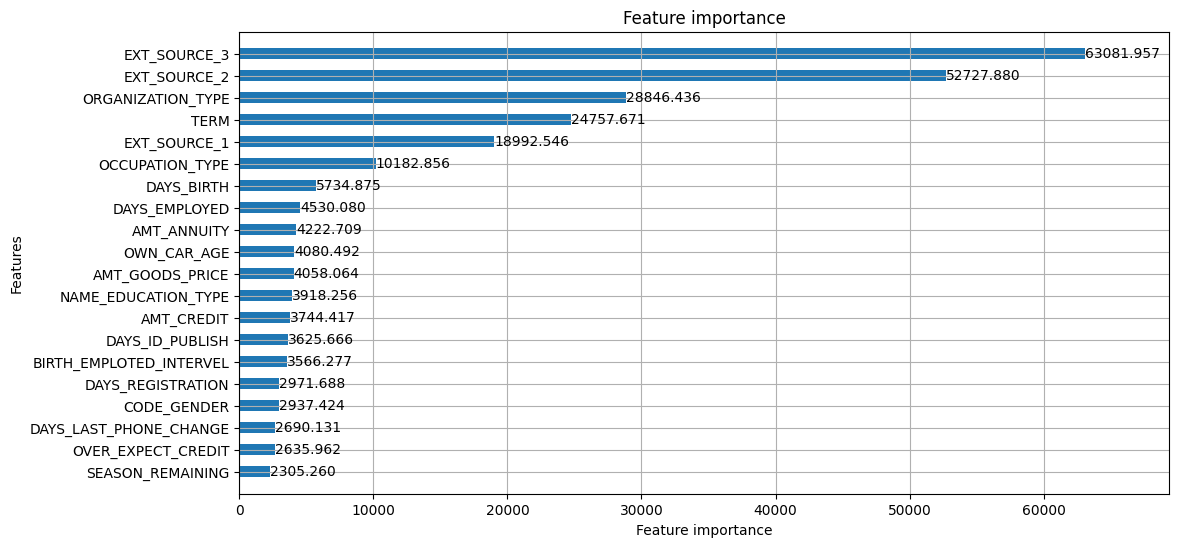

In [67]:
lgb.plot_importance(lgb_es_model, height=0.5, max_num_features=20, ignore_zero = False, figsize = (12,6), importance_type ='gain')

### <a id='4-5'>4.5 Prediction</a>

In [68]:
application_test= pd.read_csv('input/application_test.csv')
output = pd.DataFrame({'SK_ID_CURR':application_test.SK_ID_CURR, 'TARGET': sub_preds})
output.to_csv('only_application_pred.csv', index=False)